Mounting your Google Drive for Google Colab.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using three essential Python libraries.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# Make matplotlib show images inline
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


Uploading the input image.

In [38]:
from google.colab import files
uploaded = files.upload()

Saving DragonFly_5.png to DragonFly_5.png


Displaying the uploaded image.

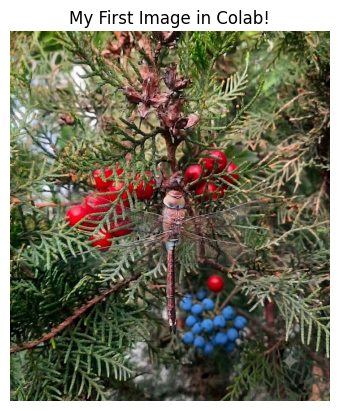

In [39]:
# Read the image
image_name = list(uploaded.keys())[0]  # Get the name of the uploaded file
image = cv2.imread(image_name)

# Convert BGR (OpenCV default) to RGB (Matplotlib default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.title("My First Image in Colab!")
plt.axis('off')  # Turn off axes
plt.show()

Examining the fundamental properties of our image.

In [48]:
# Print image properties
print(f"Image shape: {image.shape}")
print(f"Image data type: {image.dtype}")
print(f"Number of pixels: {image.shape[0] * image.shape[1]}")

# For color images, shape = (height, width, channels)
if len(image.shape) == 3:
    height, width, channels = image.shape
    print(f"Height: {height} pixels")
    print(f"Width: {width} pixels")
    print(f"Number of color channels: {channels}")

# Access a specific pixel
row, col = 100, 150
pixel_bgr = image[row, col]
pixel_rgb = image_rgb[row, col]
print(f"\nPixel at ({row}, {col}):")
print(f"  BGR: {pixel_bgr}")
print(f"  RGB: {pixel_rgb}")

Image shape: (1024, 886, 3)
Image data type: uint8
Number of pixels: 907264
Height: 1024 pixels
Width: 886 pixels
Number of color channels: 3

Pixel at (100, 150):
  BGR: [109 163 156]
  RGB: [156 163 109]


Separating the image into its three color channels and visualize each.

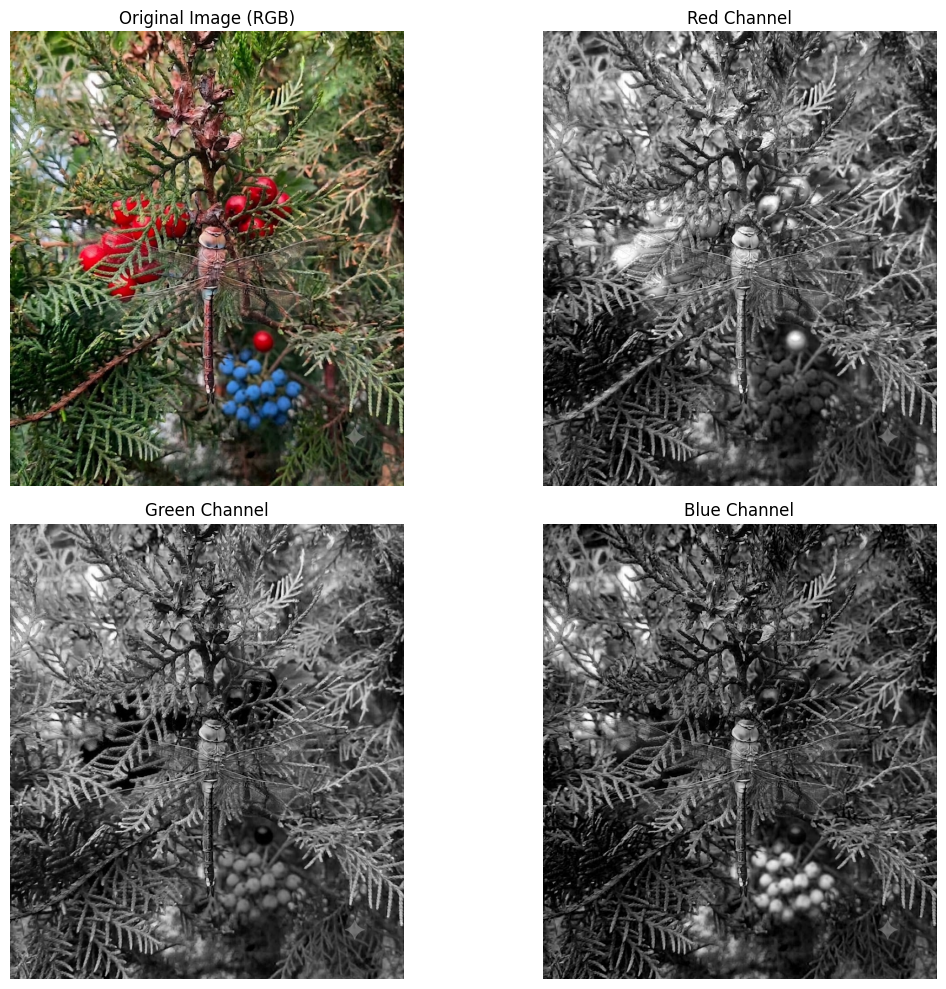

In [49]:
# Split the RGB image into channels
R = image_rgb[:, :, 0]  # Red channel
G = image_rgb[:, :, 1]  # Green channel
B = image_rgb[:, :, 2]  # Blue channel

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original image
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title('Original Image (RGB)')
axes[0, 0].axis('off')

# Red channel
axes[0, 1].imshow(R, cmap='gray')
axes[0, 1].set_title('Red Channel')
axes[0, 1].axis('off')

# Green channel
axes[1, 0].imshow(G, cmap='gray')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

# Blue channel
axes[1, 1].imshow(B, cmap='gray')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

See what is inside the image matrix.

In [51]:
print(image_rgb)

[[[ 45  52   0]
  [ 80  87  33]
  [114 119  65]
  ...
  [ 51  71  18]
  [ 55  75  24]
  [ 51  71  20]]

 [[ 62  69  15]
  [ 92  99  45]
  [119 124  70]
  ...
  [ 55  75  22]
  [ 56  76  25]
  [ 50  70  19]]

 [[ 81  88  34]
  [104 111  57]
  [122 127  71]
  ...
  [ 63  83  30]
  [ 62  82  29]
  [ 52  72  19]]

 ...

 [[ 78 106  58]
  [ 74 102  54]
  [ 71  99  51]
  ...
  [108 110  71]
  [ 87  92  52]
  [ 45  50  10]]

 [[ 76 106  56]
  [ 60  90  40]
  [ 52  82  32]
  ...
  [120 122  82]
  [ 99 104  63]
  [ 54  59  18]]

 [[ 43  73  21]
  [ 36  66  14]
  [ 36  66  16]
  ...
  [123 126  83]
  [111 116  75]
  [ 73  78  37]]]


Making Red Pixels White.

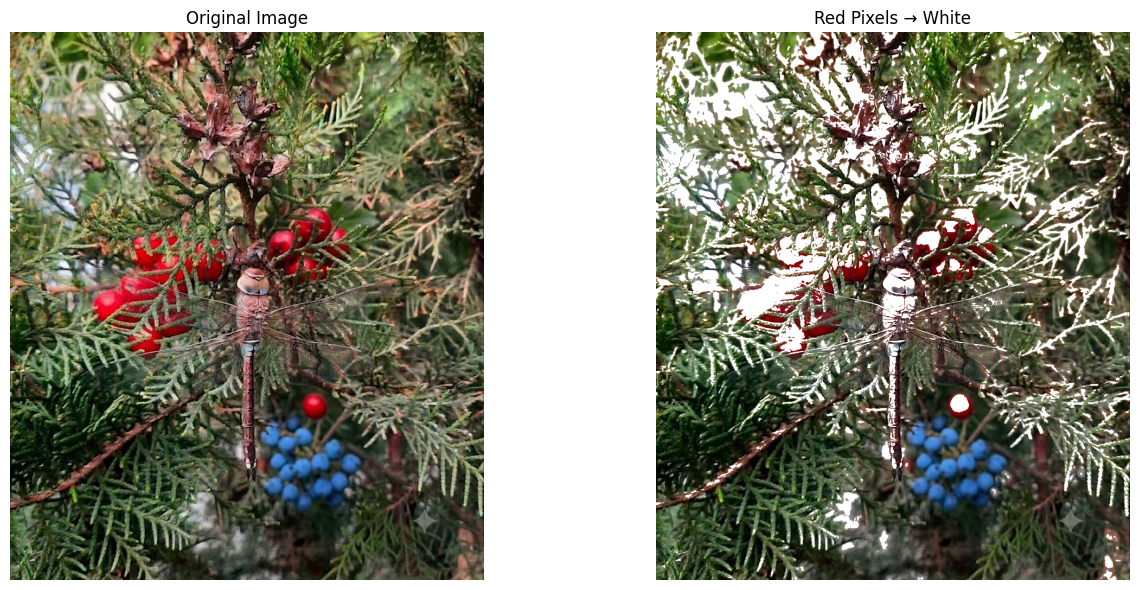

In [53]:
# Create a copy of the original image
modified = image_rgb.copy()

# Get the image dimensions
height, width, channels = modified.shape

# Apply the condition to every pixel
for i in range(height):
    for j in range(width):
        r, g, b = modified[i, j]
        if r > 150:  # If Red is very high
            modified[i, j] = [255, 255, 255]  # Turn to white

# Display original and modified side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(modified)
ax2.set_title('Red Pixels → White')
ax2.axis('off')

plt.tight_layout()
plt.show()

Green Dominance Filter.

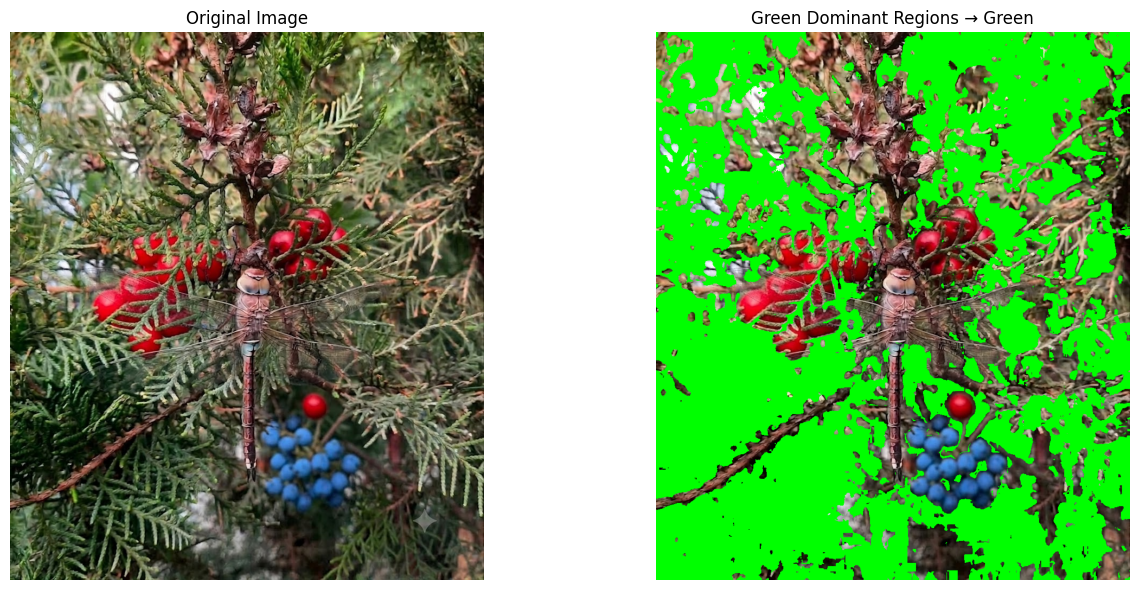

In [42]:
modified = image_rgb.copy()

for i in range(height):
    for j in range(width):
        r, g, b = modified[i, j]
        if g > r and g > b:  # Green dominates
            modified[i, j] = [0, 255, 0]  # Pure green

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(modified)
ax2.set_title('Green Dominant Regions → Green')
ax2.axis('off')

plt.tight_layout()
plt.show()

Blue Filter (Keep Only Blue).

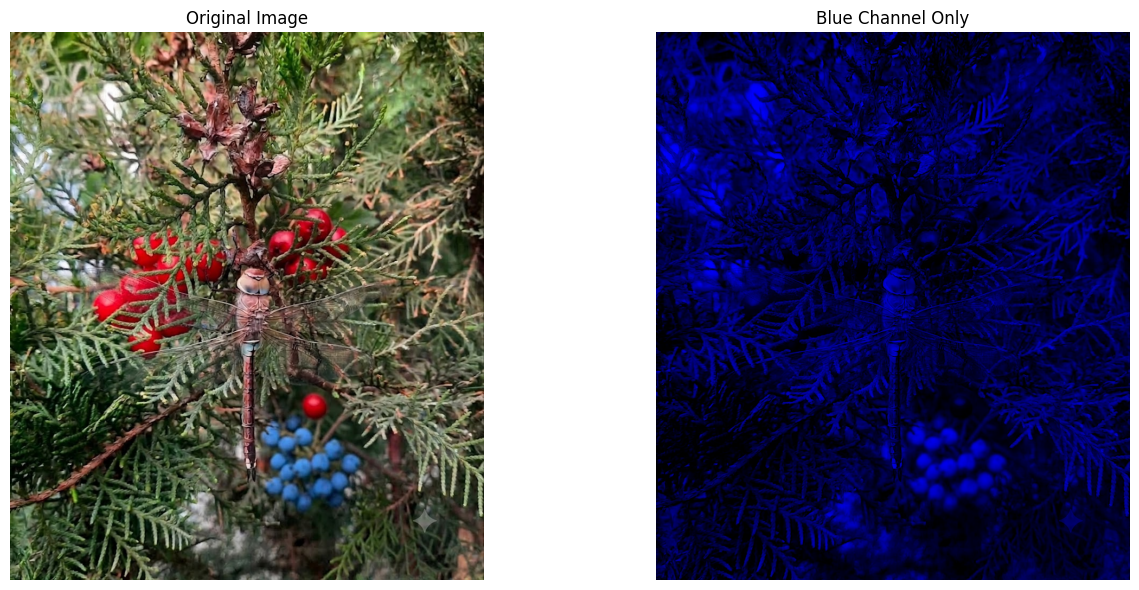

In [43]:
blue_only = image_rgb.copy()

for i in range(height):
    for j in range(width):
        # Set Red and Green channels to zero
        blue_only[i, j, 0] = 0  # Red = 0
        blue_only[i, j, 1] = 0  # Green = 0
        # Blue remains unchanged

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(blue_only)
ax2.set_title('Blue Channel Only')
ax2.axis('off')

plt.tight_layout()
plt.show()

Drawing a Black Rectangle in the Middle.

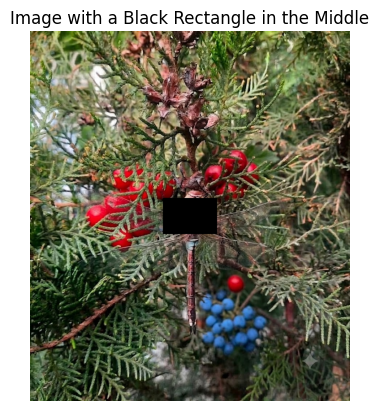

In [44]:
drawn = image_rgb.copy()

# Calculate the center of the image
center_h, center_w = height // 2, width // 2

# Rectangle dimensions
rect_h, rect_w = 100, 150

# Draw the rectangle
for i in range(center_h - rect_h//2, center_h + rect_h//2):
    for j in range(center_w - rect_w//2, center_w + rect_w//2):
        drawn[i, j] = [0, 0, 0]  # Black rectangle

plt.imshow(drawn)
plt.title('Image with a Black Rectangle in the Middle')
plt.axis('off')
plt.show()

Drawing a Yellow Circle

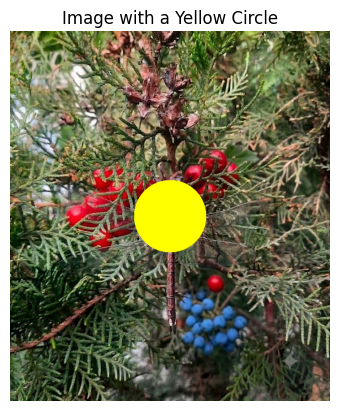

In [45]:
drawn = image_rgb.copy()

# Circle center and radius
circle_center = (width // 2, height // 2)
radius = 100

for i in range(height):
    for j in range(width):
        # Distance from center
        distance = np.sqrt((i - circle_center[1])**2 + (j - circle_center[0])**2)
        if distance <= radius:
            drawn[i, j] = [255, 255, 0]  # Yellow

plt.imshow(drawn)
plt.title('Image with a Yellow Circle')
plt.axis('off')
plt.show()

Creating a Green Border.

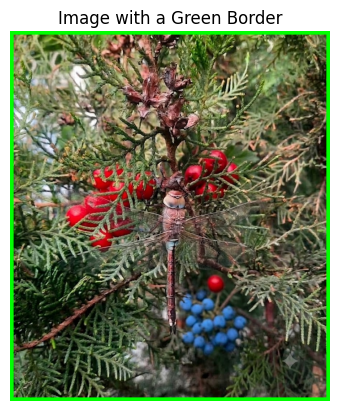

In [46]:
drawn = image_rgb.copy()
border_size = 10

for i in range(height):
    for j in range(width):
        # Check if pixel is on the border
        if i < border_size or i >= height - border_size or j < border_size or j >= width - border_size:
            drawn[i, j] = [0, 255, 0]  # Green

plt.imshow(drawn)
plt.title('Image with a Green Border')
plt.axis('off')
plt.show()

Performance Comparison: Loops vs. Vectorization (The full code is not in the book)

Saving DragonFly_5.png to DragonFly_5 (1).png
Image size: 1024 x 886 pixels
Total pixels: 907,264

Method 1: Nested Loops (Our approach)
   Time: 0.4234 seconds

Method 2: Vectorized (NumPy mask)
   Time: 0.0112 seconds

Method 3: Vectorized with Dominance Check
   Time: 0.0115 seconds

Method 4: Vectorized with Margin (r > g + 30 and r > b + 30)
   Time: 0.0117 seconds

PERFORMANCE COMPARISON SUMMARY

   Method                              Time (seconds)  Speedup   
   ------------------------------------------------------------
   1. Nested Loops (r > 150)           0.4234          1.00x     
   2. Vectorized (r > 150)             0.0112          37.88x
   3. Vectorized (dominance)           0.0115          36.71x
   4. Vectorized (margin)              0.0117          36.29x

   ------------------------------------------------------------

   Vectorization is 38x faster than nested loops!


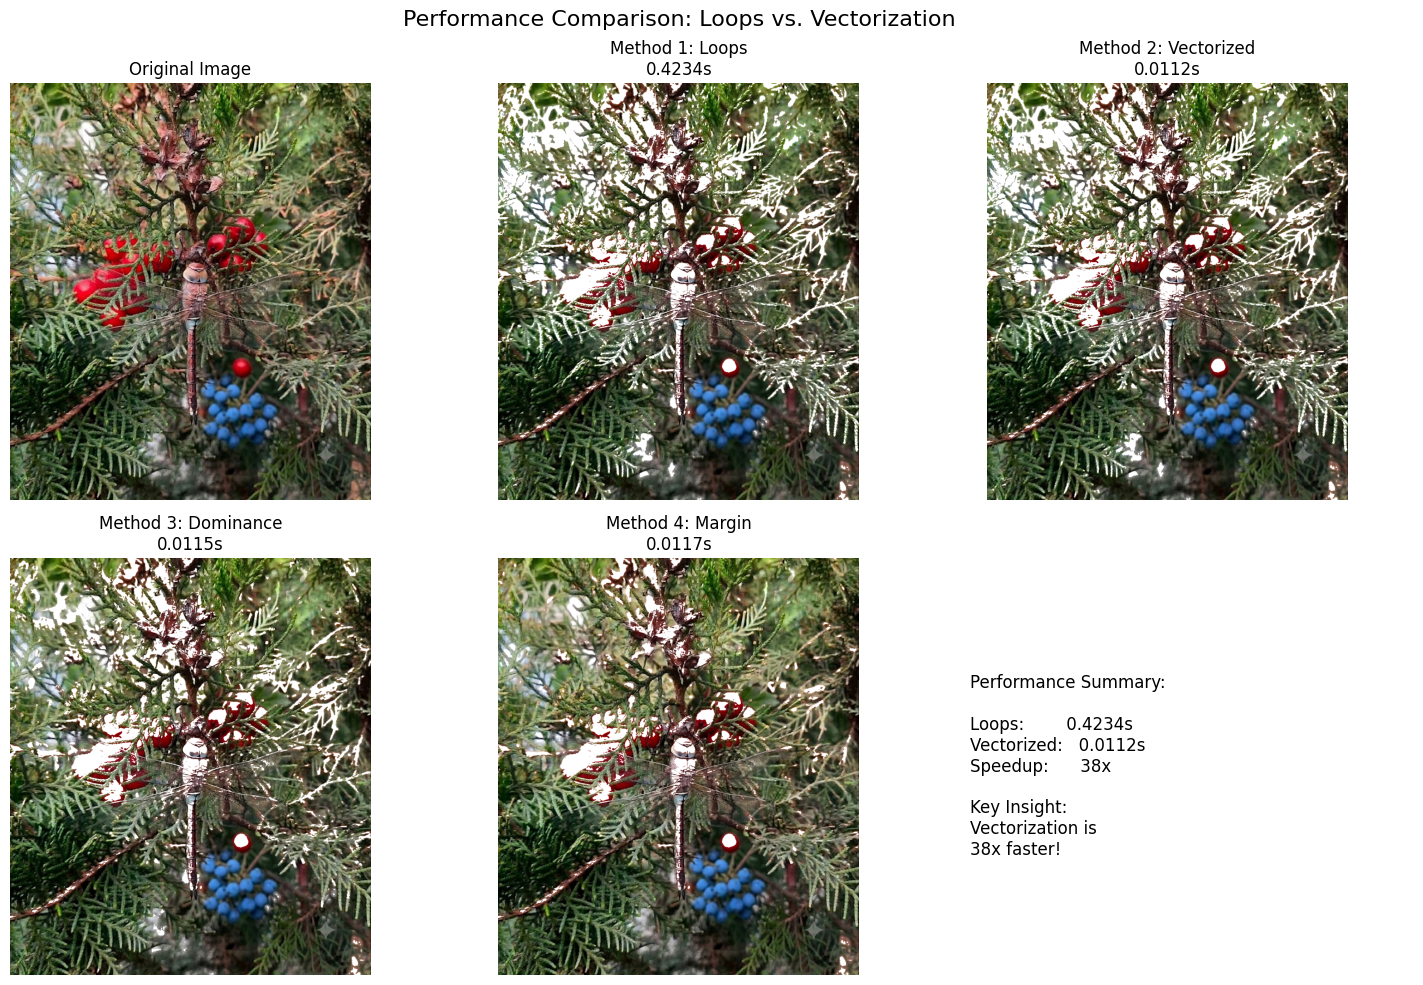


Verifying Results are Identical:
   Method 1 and Method 2 produce identical results
   Method 3 differs (dominance condition)
   Method 4 differs (margin condition)

Performance test complete!


In [47]:
# ============================================
# Performance Comparison: Loops vs. Vectorization
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files

# Upload an image
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Load and prepare the image
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width, channels = image_rgb.shape

print(f"Image size: {height} x {width} pixels")
print(f"Total pixels: {height * width:,}\n")

# ============================================
# Method 1: Nested Loops (Pedagogical)
# ============================================

print("Method 1: Nested Loops (Our approach)")

# Create a copy for each method to ensure fair comparison
modified_loops = image_rgb.copy()

start = time.time()
for i in range(height):
    for j in range(width):
        if modified_loops[i, j, 0] > 150:
            modified_loops[i, j] = [255, 255, 255]
end = time.time()

time_loops = end - start
print(f"   Time: {time_loops:.4f} seconds")

# ============================================
# Method 2: Vectorized (NumPy mask)
# ============================================

print("\nMethod 2: Vectorized (NumPy mask)")

modified_vectorized = image_rgb.copy()

start = time.time()
mask = modified_vectorized[:, :, 0] > 150
modified_vectorized[mask] = [255, 255, 255]
end = time.time()

time_vectorized = end - start
print(f"   Time: {time_vectorized:.4f} seconds")

# ============================================
# Method 3: Vectorized with Dominance Check
# ============================================

print("\nMethod 3: Vectorized with Dominance Check")

modified_dominant = image_rgb.copy()

start = time.time()
mask = (modified_dominant[:, :, 0] > 150) & (modified_dominant[:, :, 0] > modified_dominant[:, :, 1]) & (modified_dominant[:, :, 0] > modified_dominant[:, :, 2])
modified_dominant[mask] = [255, 255, 255]
end = time.time()

time_dominant = end - start
print(f"   Time: {time_dominant:.4f} seconds")

# ============================================
# Method 4: Vectorized with Margin
# ============================================

print("\nMethod 4: Vectorized with Margin (r > g + 30 and r > b + 30)")

modified_margin = image_rgb.copy()

start = time.time()
mask = (modified_margin[:, :, 0] > modified_margin[:, :, 1] + 30) & (modified_margin[:, :, 0] > modified_margin[:, :, 2] + 30) & (modified_margin[:, :, 0] > 150)
modified_margin[mask] = [255, 255, 255]
end = time.time()

time_margin = end - start
print(f"   Time: {time_margin:.4f} seconds")

# ============================================
# Results Summary
# ============================================

print("\n" + "="*50)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*50)

print(f"\n   {'Method':<35} {'Time (seconds)':<15} {'Speedup':<10}")
print("   " + "-"*60)

print(f"   {'1. Nested Loops (r > 150)':<35} {time_loops:<15.4f} {'1.00x':<10}")
print(f"   {'2. Vectorized (r > 150)':<35} {time_vectorized:<15.4f} {time_loops/time_vectorized:.2f}x")
print(f"   {'3. Vectorized (dominance)':<35} {time_dominant:<15.4f} {time_loops/time_dominant:.2f}x")
print(f"   {'4. Vectorized (margin)':<35} {time_margin:<15.4f} {time_loops/time_margin:.2f}x")

print("\n   " + "-"*60)
print(f"\n   Vectorization is {time_loops/time_vectorized:.0f}x faster than nested loops!")

# ============================================
# Visualize the Results Side by Side
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Method 1: Loops
axes[0, 1].imshow(modified_loops)
axes[0, 1].set_title(f'Method 1: Loops\n{time_loops:.4f}s')
axes[0, 1].axis('off')

# Method 2: Vectorized
axes[0, 2].imshow(modified_vectorized)
axes[0, 2].set_title(f'Method 2: Vectorized\n{time_vectorized:.4f}s')
axes[0, 2].axis('off')

# Method 3: Dominance
axes[1, 0].imshow(modified_dominant)
axes[1, 0].set_title(f'Method 3: Dominance\n{time_dominant:.4f}s')
axes[1, 0].axis('off')

# Method 4: Margin
axes[1, 1].imshow(modified_margin)
axes[1, 1].set_title(f'Method 4: Margin\n{time_margin:.4f}s')
axes[1, 1].axis('off')

# Summary text
axes[1, 2].axis('off')
summary_text = f"Performance Summary:\n\n"
summary_text += f"Loops:        {time_loops:.4f}s\n"
summary_text += f"Vectorized:   {time_vectorized:.4f}s\n"
summary_text += f"Speedup:      {time_loops/time_vectorized:.0f}x\n\n"
summary_text += f"Key Insight:\nVectorization is\n{time_loops/time_vectorized:.0f}x faster!"
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center')

plt.suptitle('Performance Comparison: Loops vs. Vectorization', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# Verify Results are Identical
# ============================================

print("\nVerifying Results are Identical:")

if np.array_equal(modified_loops, modified_vectorized):
    print("   Method 1 and Method 2 produce identical results")
else:
    print("   Results differ (check conditions)")

if np.array_equal(modified_loops, modified_dominant):
    print("   Method 1 and Method 3 produce identical results")
else:
    print("   Method 3 differs (dominance condition)")

if np.array_equal(modified_loops, modified_margin):
    print("   Method 1 and Method 4 produce identical results")
else:
    print("   Method 4 differs (margin condition)")

print("\nPerformance test complete!")

In [ ]:
# Convert RGB back to BGR for OpenCV
output_image = cv2.cvtColor(drawn, cv2.COLOR_RGB2BGR)

# Save the image
output_filename = "modified_image.jpg"
cv2.imwrite(output_filename, output_image)

# Download the image
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>